# 01 - Data Ingestion

Goal for this notebook: build the DuckDB manifest (`events`) from the already-converted HDF5 data, and derive `event_outcomes` (severity labels from full trajectories). Early-window feature extraction lives in `02_feature_engineering.ipynb`.

Data: WildfireSpreadTS, Gerard et al. 2023, CC-BY-4.0. DOI: https://doi.org/10.5281/zenodo.8006177

Status: raw GeoTIFFs downloaded + unzipped, and already converted to HDF5 via the authors' `CreateHDF5Dataset.py` (see project notes -- this ran in a separate throwaway env, `wildfirespreadts-convert`, to avoid dependency conflicts with this project's own pinned versions).

## Step 1: Point at the converted HDF5 data

Both the raw GeoTIFFs and the HDF5 conversion live outside Dropbox and outside Time Machine's scope deliberately -- this is ~150GB combined of reproducible, re-downloadable/re-derivable data, not something that needs syncing or backing up.

Reminder: once we're confident we won't need to re-run the HDF5 conversion, delete the raw GeoTIFF folder (`WildfireSpreadTS/`) to drop back to just the HDF5 footprint.

In [1]:
from pathlib import Path

HDF5_DIR = Path.home() / "ml_datasets" / "flashpoint" / "hdf5"
DB_PATH = Path("../data/flashpoint.duckdb")

## Step 2: Build the event manifest

In [2]:
import sys
sys.path.insert(0, "../src")

from flashpoint.data_access import discover_hdf5_events

events = discover_hdf5_events(HDF5_DIR)
print(f"Discovered {len(events)} events")
events[:3]

Discovered 607 events


[HDF5Event(event_id='fire_21458798', year=2018, hdf5_path=PosixPath('/Users/pmacias/ml_datasets/flashpoint/hdf5/2018/fire_21458798.hdf5'), n_days=14, img_dates=['2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05', '2018-01-06', '2018-01-07', '2018-01-08', '2018-01-09', '2018-01-10', '2018-01-11', '2018-01-12', '2018-01-13', '2018-01-14'], lnglat=(np.float64(-120.26612679661682), np.float64(36.83110501866333))),
 HDF5Event(event_id='fire_21458801', year=2018, hdf5_path=PosixPath('/Users/pmacias/ml_datasets/flashpoint/hdf5/2018/fire_21458801.hdf5'), n_days=11, img_dates=['2018-01-25', '2018-01-26', '2018-01-27', '2018-01-28', '2018-01-29', '2018-01-30', '2018-01-31', '2018-02-01', '2018-02-02', '2018-02-03', '2018-02-04'], lnglat=(np.float64(-112.23015793803805), np.float64(36.72948681020297))),
 HDF5Event(event_id='fire_21458806', year=2018, hdf5_path=PosixPath('/Users/pmacias/ml_datasets/flashpoint/hdf5/2018/fire_21458806.hdf5'), n_days=19, img_dates=['2018-01-12', '20

## Step 3: Load manifest + derive severity labels into DuckDB

In [3]:
from tqdm import tqdm
from flashpoint.db import get_connection
from flashpoint.data_access import read_channel_all_days, ACTIVE_FIRE_CHANNEL_IDX
from flashpoint.labels import max_area_ha

con = get_connection(DB_PATH)

# Populate `events` -- one row per discovered HDF5Event
events_rows = [
    (e.event_id, e.year, str(e.hdf5_path), e.n_days, e.lnglat[0], e.lnglat[1])
    for e in events
]
con.executemany("INSERT OR REPLACE INTO events VALUES (?, ?, ?, ?, ?, ?)", events_rows)

# Populate `event_outcomes` -- PEAK active-fire extent across the whole
# trajectory, not the last day (buffer days at the start/end of each event
# frequently show zero detected fire -- 56.5% of events had final_area_ha == 0
# when we first tried the last-day version, which would have mislabeled
# large, later-contained fires as "severity 0"). Reads only the active-fire
# channel across all days, not the full 23-channel stack, to keep this fast.
# severity_class is left NULL for now -- Step 4 looks at the distribution first.
outcome_rows = []
for e in tqdm(events):
    af_all_days = read_channel_all_days(e, ACTIVE_FIRE_CHANNEL_IDX)  # (n_days, H, W)
    peak_ha = max_area_ha(af_all_days)
    outcome_rows.append((e.event_id, peak_ha, e.n_days, None))

con.executemany("INSERT OR REPLACE INTO event_outcomes VALUES (?, ?, ?, ?)", outcome_rows)
con.commit()
print(f"Inserted {len(events_rows)} events, {len(outcome_rows)} outcomes")

100%|██████████| 607/607 [00:04<00:00, 135.11it/s]


Inserted 607 events, 607 outcomes


## Step 4: Look at the max_area_ha distribution, THEN set severity bin edges

The paper doesn't report a "peak size" histogram directly (it reports fire
duration, concentrated 14-20 days with a long tail to 94 days, and per-frame
pixel-change stats -- not peak extent), so there's no shortcut here: look
at the actual distribution below, then set `labels.severity_class`'s bin
edges from that -- not from a guess.


count       607.000000
mean       7016.260811
std       12208.656090
min          56.250000
25%        1378.125000
50%        2981.250000
75%        7185.937500
max      128446.875000
Name: max_area_ha, dtype: float64


<Axes: >

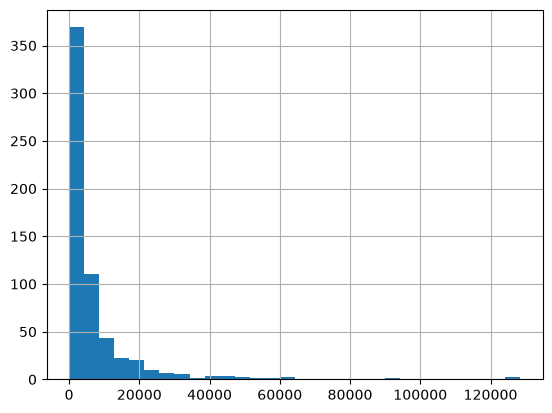

In [4]:
df = con.execute("SELECT * FROM event_outcomes").df()
print(df['max_area_ha'].describe())
df['max_area_ha'].hist(bins=30)

Also worth checking here:
- Class balance once bins are set (`SELECT year, COUNT(*) FROM events GROUP BY year`)
- 2019 is a known outlier year in the source data (fewer, smaller fires) -- worth
  keeping in mind for later year-based train/val/test splits, per the paper's
  own recommendation
- Any events too short to support a day-1/day-2 early cutoff (`n_days < 3`)

## Step 5: Set severity_class from quartiles and write it back

`max_area_ha` is heavily right-skewed (median well below mean, long tail),
so quartile-based bins are used rather than fixed hectare cutoffs -- this
keeps the four severity tiers roughly balanced instead of dumping most
events into one bin.

In [5]:
from flashpoint.labels import severity_class

bin_edges = df['max_area_ha'].quantile([0.25, 0.5, 0.75]).tolist()
print(f"Quartile bin edges (ha): {bin_edges}")

df['severity_class'] = df['max_area_ha'].apply(lambda ha: severity_class(ha, bin_edges))
print(df['severity_class'].value_counts().sort_index())

# Write severity_class back to event_outcomes
update_rows = list(zip(df['severity_class'].tolist(), df['event_id'].tolist()))
con.executemany("UPDATE event_outcomes SET severity_class = ? WHERE event_id = ?", update_rows)
con.commit()
print("severity_class written back to event_outcomes")

Quartile bin edges (ha): [1378.125, 2981.25, 7185.9375]
severity_class
0    155
1    149
2    152
3    151
Name: count, dtype: int64
severity_class written back to event_outcomes


In [6]:
con.close()